# GridSense
## Community Outage-Report Risk Forecasting for Addis Ababa

GridSense is a local forecasting project focused on a real Addis Ababa issue: electricity interruptions that affect studying, small businesses, online work, charging, and daily planning.

This notebook builds a community-report forecasting pipeline and evaluates whether time, location, weather, and planning-status signals can estimate **reported outage risk** in local time windows.


## Local Motivation

In Addis Ababa, power cuts are not abstract infrastructure events. They directly affect people's routines and productivity. This project treats outage data as a community planning problem: can we generate early risk signals that help people prepare?


## Research Questions

1. When are electricity outages most likely to be reported in Addis Ababa?
2. Which sub-cities and time windows show higher reported outage risk?
3. Are rainy/stormy conditions associated with higher reported outage risk or longer duration?
4. Can time, location, weather, and planning-status features estimate outage-report probability?
5. If an outage is reported, can we estimate likely severity or duration?


## Data Collection and Privacy

The community outage reports were collected through an anonymous reporting form shared with Addis Ababa residents. Respondents reported general outage information such as sub-city, sefer/landmark, approximate time, duration, planning status, impact level, and weather condition.

No names, phone numbers, emails, exact addresses, GPS coordinates, or free-text personal notes are used in the public analysis dataset.


## Important Truth-vs-Signal Framing

GridSense does not observe full utility telemetry. It observes community reports.

Therefore, the Stage 1 target is:
- `outage_reported` = whether at least one outage report was captured for a sub-city/time-window.

A window labelled `outage_reported = 0` means no outage report was captured in the community dataset for that sub-city and time window. It does not prove electricity was available everywhere in that area. Therefore, GridSense predicts a community-report signal, not official outage occurrence.


## Data Pipeline Diagram

```text
Raw anonymous community reports
        ->
Privacy cleaning
        ->
Event-level outage dataset
        ->
3-hour sub-city window aggregation
        ->
Forecasting dataset: outage_reported
        ->
Stage 1: community outage-report risk model
        ->
Stage 2: severity/duration model
        ->
Planning insights for local users
```


## Kujenga Concept Map

| Kujenga concept | Where it appears in GridSense |
|---|---|
| Regression | Duration modeling (`avg_duration_hours`) |
| T-test | Rainy/stormy vs non-rainy duration comparison |
| Mathematical modelling | Report-to-window risk target construction |
| Dynamic systems thinking | Risk varies by time window, place, and weather |
| Data storytelling | Local Addis-focused interpretation with limits |


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
GITHUB_RAW_BASE = 'https://raw.githubusercontent.com/lisan-5/GridSense/main'

# Stratified CV object used in Stage 1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [2]:
# Self-contained data loading from GitHub raw URLs with local fallback
community_candidates = [
    f"{GITHUB_RAW_BASE}/data/processed/community_outage_reports_clean.csv",
    str(ROOT / 'data/processed/community_outage_reports_clean.csv')
]

loaded = None
for c in community_candidates:
    try:
        if c.startswith('http'):
            community_raw = pd.read_csv(c)
        else:
            community_raw = pd.read_csv(Path(c))
        loaded = c
        break
    except Exception:
        pass

if loaded is None:
    raise RuntimeError('Could not load community dataset from GitHub or local path.')

print('Loaded community dataset from:', loaded)
print('shape:', community_raw.shape)
community_raw.head(3)


Loaded community dataset from: https://raw.githubusercontent.com/lisan-5/GridSense/main/data/processed/community_outage_reports_clean.csv
shape: (198, 13)


,report_id,date,sub_city,sefer_or_landmark,outage_start_time,outage_end_time,duration_hours,planned_notice,impact_level,weather_condition,source_type,confidence_score,high_risk_outage
0,COMM-00001,2026-04-12,Bole,Rwanda,03:00,05:01,2.02,no,medium,clear,streamlit_form,0.62,1
1,COMM-00002,2026-04-13,Gulele,Shiro Meda,23:00,23:23,0.39,yes,low,cloudy,streamlit_form,0.76,0
2,COMM-00003,2026-04-14,Akaki Kality,Kality,16:00,16:39,0.65,no,low,cloudy,streamlit_form,0.56,0


In [3]:
# Build forecasting dataset in-notebook for reproducibility
community = community_raw.copy()
community['date'] = pd.to_datetime(community['date'], errors='coerce')
community['duration_hours'] = pd.to_numeric(community['duration_hours'], errors='coerce')
community['confidence_score'] = pd.to_numeric(community.get('confidence_score', 0.6), errors='coerce')
for col in ['sub_city','sefer_or_landmark','weather_condition','impact_level','planned_notice']:
    if col in community.columns:
        community[col] = community[col].astype(str).str.strip().str.lower()

start_dt = pd.to_datetime(
    community['date'].dt.strftime('%Y-%m-%d') + ' ' + community['outage_start_time'].astype(str),
    errors='coerce'
)
community['hour'] = start_dt.dt.hour.fillna(0).astype(int)
community['hour_block_start'] = (community['hour'] // 3) * 3
community['time_window'] = community['hour_block_start'].apply(lambda h: f"{h:02d}:00-{(h+3)%24:02d}:00")
community['day_of_week'] = community['date'].dt.day_name().fillna('Unknown')
community['is_rainy'] = community['weather_condition'].str.contains('rain|storm', case=False, na=False).astype(int)

community['outage_proxy'] = ((community['duration_hours'] > 1.0) | (community['impact_level'].isin(['medium','high','critical']))).astype(int)
community['high_severity_proxy'] = ((community['duration_hours'] >= 2.5) | (community['impact_level'].isin(['high','critical']))).astype(int)

agg_cols = ['date','sub_city','hour_block_start','time_window','day_of_week']
agg = community.groupby(agg_cols, dropna=False).agg(
    reports_count=('outage_proxy','size'),
    outage_reported=('outage_proxy','max'),
    avg_duration_hours=('duration_hours','mean'),
    max_duration_hours=('duration_hours','max'),
    high_severity_outage=('high_severity_proxy','max'),
    weather_condition=('weather_condition', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    is_rainy=('is_rainy','max'),
    planned_notice_mode=('planned_notice', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    representative_sefer=('sefer_or_landmark', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    confidence_score_mean=('confidence_score','mean')
).reset_index()

dates = sorted(agg['date'].dropna().unique())
sub_cities = sorted(agg['sub_city'].dropna().unique())
blocks = sorted(agg['hour_block_start'].dropna().unique())
full = pd.MultiIndex.from_product([dates, sub_cities, blocks], names=['date','sub_city','hour_block_start']).to_frame(index=False)
full['time_window'] = full['hour_block_start'].apply(lambda h: f"{h:02d}:00-{(h+3)%24:02d}:00")
full['day_of_week'] = pd.to_datetime(full['date']).dt.day_name()

forecast_df = full.merge(agg, on=['date','sub_city','hour_block_start','time_window','day_of_week'], how='left')
forecast_df['reports_count'] = forecast_df['reports_count'].fillna(0).astype(int)
forecast_df['outage_reported'] = forecast_df['outage_reported'].fillna(0).astype(int)
forecast_df['high_severity_outage'] = forecast_df['high_severity_outage'].fillna(0).astype(int)
forecast_df['avg_duration_hours'] = forecast_df['avg_duration_hours'].fillna(0.0)
forecast_df['max_duration_hours'] = forecast_df['max_duration_hours'].fillna(0.0)
forecast_df['weather_condition'] = forecast_df['weather_condition'].fillna('unknown')
forecast_df['is_rainy'] = forecast_df['is_rainy'].fillna(0).astype(int)
forecast_df['planned_notice_mode'] = forecast_df['planned_notice_mode'].fillna('unknown')
forecast_df['representative_sefer'] = forecast_df['representative_sefer'].fillna('unknown')
forecast_df['confidence_score_mean'] = forecast_df['confidence_score_mean'].fillna(0.0)
forecast_df['respondents_count_proxy'] = forecast_df['reports_count']

print('forecast_df shape:', forecast_df.shape)
print('outage_reported counts:')
print(forecast_df['outage_reported'].value_counts())
forecast_df.head(3)


forecast_df shape: (1584, 16)
outage_reported counts:
outage_reported
0    1489
1      95
Name: count, dtype: int64


,date,sub_city,hour_block_start,time_window,day_of_week,reports_count,outage_reported,avg_duration_hours,max_duration_hours,high_severity_outage,weather_condition,is_rainy,planned_notice_mode,representative_sefer,confidence_score_mean,respondents_count_proxy
0,2026-04-12,addis ketema,0,00:00-03:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
1,2026-04-12,addis ketema,3,03:00-06:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
2,2026-04-12,addis ketema,6,06:00-09:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0


## Exploratory Analysis (Local risk signals)


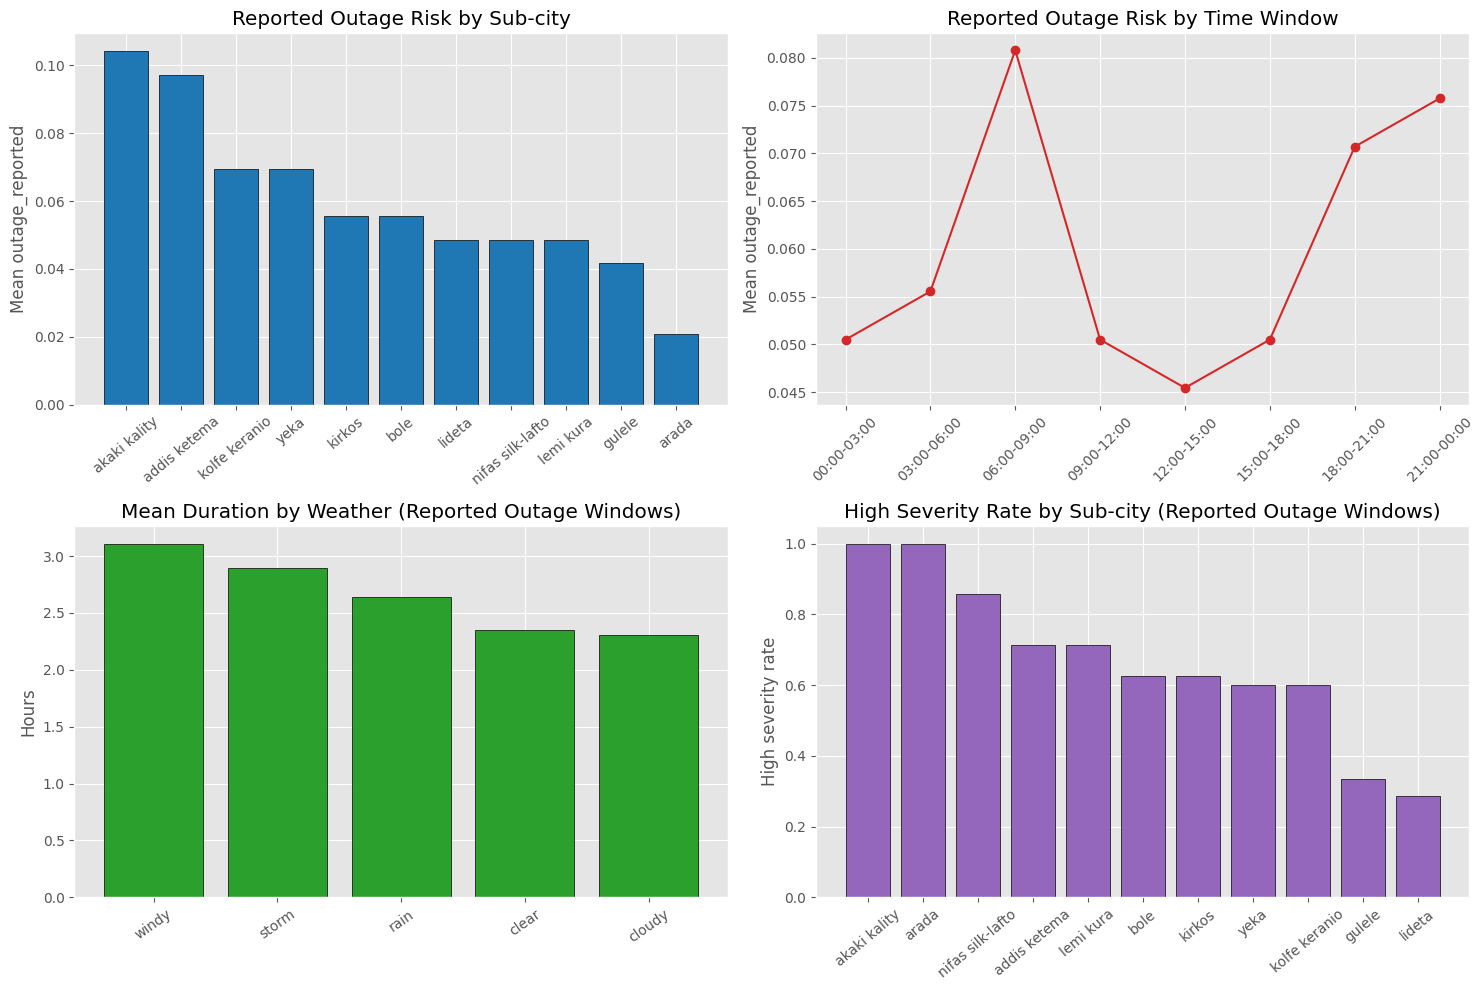

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

city_risk = forecast_df.groupby('sub_city')['outage_reported'].mean().sort_values(ascending=False)
axes[0,0].bar(city_risk.index, city_risk.values, color='#1f77b4', edgecolor='black')
axes[0,0].set_title('Reported Outage Risk by Sub-city')
axes[0,0].tick_params(axis='x', rotation=40)
axes[0,0].set_ylabel('Mean outage_reported')

tw_risk = forecast_df.groupby('time_window')['outage_reported'].mean().sort_index()
axes[0,1].plot(tw_risk.index, tw_risk.values, marker='o', color='#d62728')
axes[0,1].set_title('Reported Outage Risk by Time Window')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylabel('Mean outage_reported')

out_df = forecast_df[forecast_df['outage_reported']==1]
w_dur = out_df.groupby('weather_condition')['avg_duration_hours'].mean().sort_values(ascending=False)
axes[1,0].bar(w_dur.index, w_dur.values, color='#2ca02c', edgecolor='black')
axes[1,0].set_title('Mean Duration by Weather (Reported Outage Windows)')
axes[1,0].tick_params(axis='x', rotation=35)
axes[1,0].set_ylabel('Hours')

sev = out_df.groupby('sub_city')['high_severity_outage'].mean().sort_values(ascending=False)
axes[1,1].bar(sev.index, sev.values, color='#9467bd', edgecolor='black')
axes[1,1].set_title('High Severity Rate by Sub-city (Reported Outage Windows)')
axes[1,1].tick_params(axis='x', rotation=40)
axes[1,1].set_ylabel('High severity rate')

plt.tight_layout()
plt.show()


## Local Risk Surface (Sub-city x Time Window)

This view translates the dataset into a practical planning map. Darker cells indicate higher **reported outage risk** in that sub-city/time-window combination.

Interpretation rule:
- This is a **community signal** (where reports were captured), not official utility telemetry.
- Use it to identify where residents and small businesses may need stronger preparation habits.


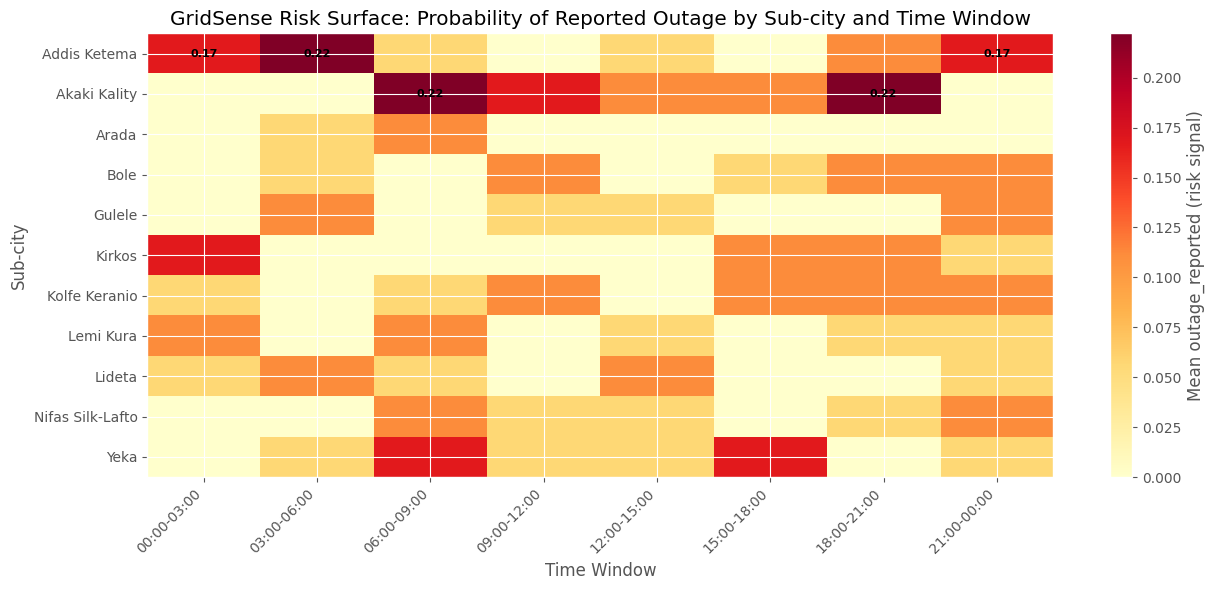

Top 5 risk signal cells:
       sub_city  time_window      risk
0  addis ketema  03:00-06:00  0.222222
1  akaki kality  06:00-09:00  0.222222
2  akaki kality  18:00-21:00  0.222222
3  addis ketema  00:00-03:00  0.166667
4  addis ketema  21:00-00:00  0.166667


In [5]:
risk_surface = (forecast_df.groupby(['sub_city','time_window'])['outage_reported']
                .mean()
                .unstack(fill_value=0)
                .reindex(columns=sorted(forecast_df['time_window'].unique())))

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(risk_surface.values, aspect='auto', cmap='YlOrRd')
ax.set_title('GridSense Risk Surface: Probability of Reported Outage by Sub-city and Time Window')
ax.set_xlabel('Time Window')
ax.set_ylabel('Sub-city')
ax.set_xticks(range(len(risk_surface.columns)))
ax.set_xticklabels(risk_surface.columns, rotation=45, ha='right')
ax.set_yticks(range(len(risk_surface.index)))
ax.set_yticklabels([s.title() for s in risk_surface.index])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mean outage_reported (risk signal)')

# Annotate highest-risk cells for quick reading
flat = (risk_surface.stack().sort_values(ascending=False).head(5))
for (sub, tw), val in flat.items():
    y = list(risk_surface.index).index(sub)
    x = list(risk_surface.columns).index(tw)
    ax.text(x, y, f'{val:.2f}', ha='center', va='center', color='black', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('Top 5 risk signal cells:')
print(flat.rename('risk').reset_index().rename(columns={'level_0':'sub_city','level_1':'time_window'}))

## Statistical test (rainy/stormy vs non-rainy duration)

Interpretation target: if p-value is high and Cohen's d is small, we treat weather-duration differences as weak in this sample.


In [6]:
rainy = out_df[out_df['is_rainy']==1]['avg_duration_hours'].dropna()
non_rainy = out_df[out_df['is_rainy']==0]['avg_duration_hours'].dropna()
t_stat, p_value = ttest_ind(rainy, non_rainy, alternative='greater', equal_var=False)

def cohens_d(x,y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean()-y.mean())/pooled

print('rainy mean:', round(rainy.mean(),2), 'hours')
print('non-rainy mean:', round(non_rainy.mean(),2), 'hours')
print('t-stat:', round(float(t_stat),4), 'p-value:', round(float(p_value),6))
if len(rainy)>1 and len(non_rainy)>1:
    print("Cohen's d:", round(float(cohens_d(rainy,non_rainy)),3))


rainy mean: 2.61 hours
non-rainy mean: 2.53 hours
t-stat: 0.5379 p-value: 0.295984
Cohen's d: 0.107


## Regression (duration association)


In [7]:
reg = smf.ols('avg_duration_hours ~ hour_block_start + is_rainy + C(sub_city) + C(planned_notice_mode)', data=out_df).fit()
print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:     avg_duration_hours   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     1.548
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.113
Time:                        19:03:11   Log-Likelihood:                -97.101
No. Observations:                  95   AIC:                             224.2
Df Residuals:                      80   BIC:                             262.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

## Stage 1: Community outage-report risk model

This model estimates whether an outage was captured in community reports for a sub-city/time-window. It does not claim to observe official utility outage truth.


In [8]:
# Stage 1 feature set (leakage-safe + stronger temporal signal)
forecast_df['date'] = pd.to_datetime(forecast_df['date'], errors='coerce')
forecast_df['is_weekend'] = forecast_df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

forecast_df = forecast_df.sort_values(['sub_city','hour_block_start','date']).reset_index(drop=True)
g = forecast_df.groupby(['sub_city','hour_block_start'], dropna=False)
forecast_df['lag1_outage_reported'] = g['outage_reported'].shift(1).fillna(0).astype(int)
forecast_df['rolling3_report_rate'] = g['outage_reported'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean()).fillna(0.0)
forecast_df['hour_sin'] = np.sin(2*np.pi*forecast_df['hour_block_start']/24.0)
forecast_df['hour_cos'] = np.cos(2*np.pi*forecast_df['hour_block_start']/24.0)

stage1_features = [
    'hour_block_start','hour_sin','hour_cos','day_of_week','is_weekend','sub_city',
    'lag1_outage_reported','rolling3_report_rate'
]
X = forecast_df[stage1_features].copy()
y = forecast_df['outage_reported'].astype(int)

num = ['hour_block_start','hour_sin','hour_cos','is_weekend','lag1_outage_reported','rolling3_report_rate']
cat = ['day_of_week','sub_city']

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat),
])

# Time-based split (forecasting realism)
split_date = forecast_df['date'].dropna().quantile(0.75)
train_mask = forecast_df['date'] <= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

models = {
    'dummy_baseline': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=600, min_samples_leaf=2, class_weight='balanced_subsample', random_state=42),
}

def best_f1_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = (2*p*r)/(p+r+1e-12)
    if len(t)==0:
        return 0.5
    return float(t[np.nanargmax(f1[:-1])])

rows = []
trained = {}
for name, model in models.items():
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)
    prob_test = pipe.predict_proba(X_test)[:,1] if hasattr(pipe,'predict_proba') else np.zeros(len(X_test))
    if name == 'dummy_baseline':
        thr = 0.5
        pred_test = pipe.predict(X_test)
    else:
        prob_train = pipe.predict_proba(X_train)[:,1]
        thr = best_f1_threshold(y_train, prob_train)
        pred_test = (prob_test >= thr).astype(int)

    rows.append({
        'model': name,
        'threshold': round(float(thr),4),
        'accuracy': round(accuracy_score(y_test, pred_test),4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test, pred_test),4),
        'precision': round(precision_score(y_test, pred_test, zero_division=0),4),
        'recall': round(recall_score(y_test, pred_test, zero_division=0),4),
        'f1': round(f1_score(y_test, pred_test, zero_division=0),4),
        'roc_auc': round(roc_auc_score(y_test, prob_test),4),
        'pr_auc': round(average_precision_score(y_test, prob_test),4),
    })
    trained[name] = {'pipe': pipe, 'y_prob': prob_test, 'y_pred': pred_test, 'threshold': thr}

metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
stage1_df = metrics_df.copy()
print(f'Time split: train <= {pd.to_datetime(split_date).date()} | train={train_mask.sum()} test={(~train_mask).sum()}')
metrics_df


Time split: train <= 2026-04-25 | train=1232 test=352


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,0.5017,0.8665,0.5615,0.1515,0.2083,0.1754,0.5563,0.1599
1,logistic_regression,0.5810,0.7301,0.5269,0.0824,0.2917,0.1284,0.5182,0.1536
2,dummy_baseline,0.5000,0.9318,0.5000,0.0000,0.0000,0.0000,0.5000,0.0682


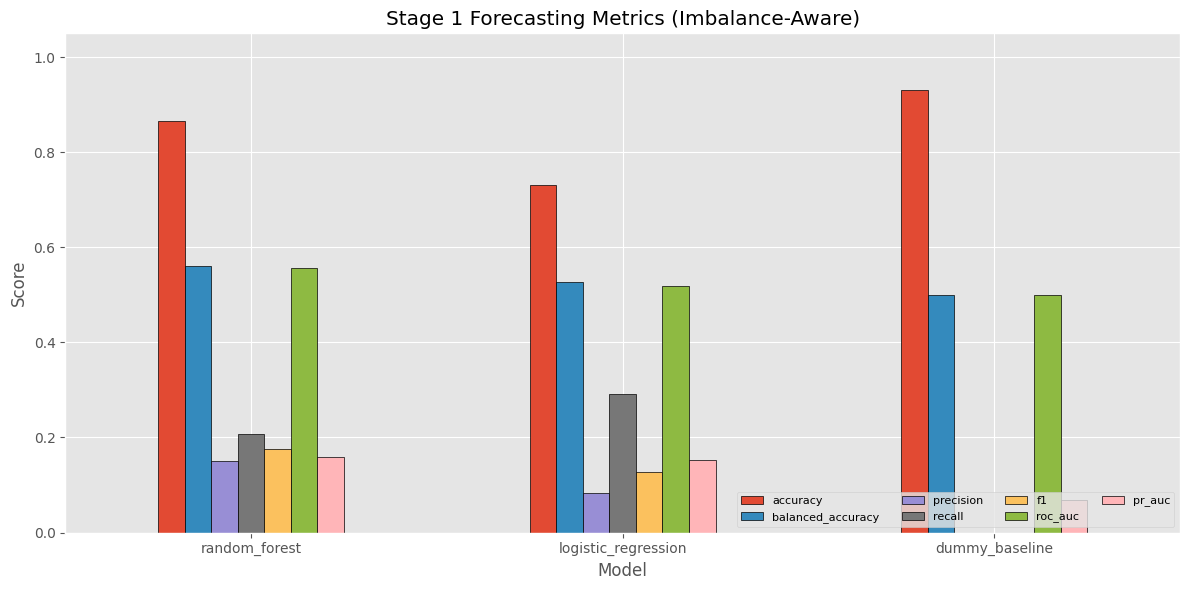

In [9]:
# Metric comparison plot (imbalance-aware)
plot_cols = ['accuracy','balanced_accuracy','precision','recall','f1','roc_auc','pr_auc']
ax = stage1_df.set_index('model')[plot_cols].plot(kind='bar', figsize=(12,6), edgecolor='black')
ax.set_title('Stage 1 Forecasting Metrics (Imbalance-Aware)')
ax.set_ylim(0,1.05)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
plt.xticks(rotation=0)
plt.legend(loc='lower right', ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


## Stage 1 Diagnostic Visuals

These plots show how well Model 1 separates high-risk windows and where it makes mistakes.

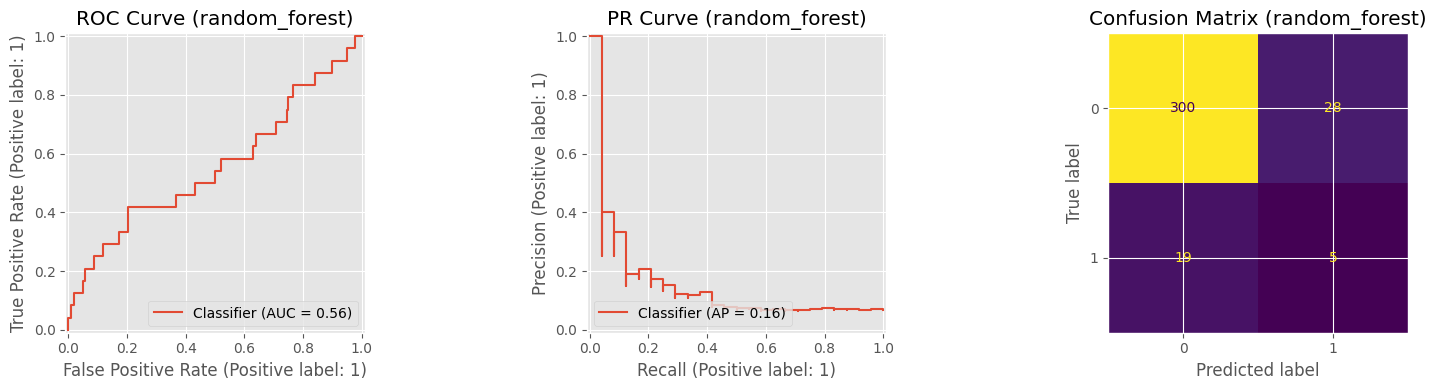

C:\Users\lisan\AppData\Local\Temp\ipykernel_37504\1427658931.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_tbl = risk_bins.groupby('bucket').agg(windows=('y','size'), observed_rate=('y','mean'), mean_pred=('p','mean')).reset_index()


,bucket,windows,observed_rate,mean_pred
0,"(-0.001, 0.2]",261,0.053640,0.096711
1,"(0.2, 0.4]",55,0.072727,0.258421
2,"(0.4, 0.6]",28,0.142857,0.543446
3,"(0.6, 0.8]",8,0.250000,0.626205
4,"(0.8, 1.0]",0,NaN,NaN


In [10]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

best_name = metrics_df.iloc[0]['model']
best_obj = trained[best_name]
y_prob_best = best_obj['y_prob']
y_pred_best = best_obj['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(16,4))
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[0])
axes[0].set_title(f'ROC Curve ({best_name})')
PrecisionRecallDisplay.from_predictions(y_test, y_prob_best, ax=axes[1])
axes[1].set_title(f'PR Curve ({best_name})')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

risk_bins = pd.DataFrame({'p': y_prob_best, 'y': y_test.values})
risk_bins['bucket'] = pd.cut(risk_bins['p'], bins=[0,0.2,0.4,0.6,0.8,1.0], include_lowest=True)
bucket_tbl = risk_bins.groupby('bucket').agg(windows=('y','size'), observed_rate=('y','mean'), mean_pred=('p','mean')).reset_index()
bucket_tbl

## Stage 1 Ablation (feature contribution)

This compares safe feature sets to show what actually adds predictive signal.


In [11]:
ablation_specs = {
    'Time only': ['hour_block_start','day_of_week'],
    'Time + location': ['hour_block_start','day_of_week','sub_city'],
}

abl_rows = []
for name, feats in ablation_specs.items():
    X_ab = forecast_df[feats].copy()
    num_ab = [f for f in feats if f in ['hour_block_start']]
    cat_ab = [f for f in feats if f not in num_ab]
    pre_ab = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_ab),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_ab)
    ])
    pipe_ab = Pipeline([('pre', pre_ab), ('model', LogisticRegression(max_iter=2000, random_state=42))])
    yhat = cross_val_predict(pipe_ab, X_ab, y, cv=cv, method='predict')
    ypr = cross_val_predict(pipe_ab, X_ab, y, cv=cv, method='predict_proba')[:,1]
    abl_rows.append({
        'Model version': name,
        'Features': ', '.join(feats),
        'F1': round(f1_score(y, yhat, zero_division=0),4),
        'PR-AUC': round(average_precision_score(y, ypr),4),
    })

ablation_df = pd.DataFrame(abl_rows)
ablation_df

,Model version,Features,F1,PR-AUC
0,Time only,"hour_block_start, day_of_week",0.0,0.0535
1,Time + location,"hour_block_start, day_of_week, sub_city",0.0,0.0645


In [12]:
# Calibration / probability buckets for best model (by F1)
best_name = stage1_df.iloc[0]['model']
best_obj = trained[best_name]
prob = best_obj['y_prob']
cal_df = pd.DataFrame({'y_true': y_test.values, 'p': prob})
cal_df['bucket'] = pd.cut(cal_df['p'], bins=[0,0.2,0.4,0.6,0.8,1.0], include_lowest=True)
cal_tbl = cal_df.groupby('bucket').agg(
    windows=('y_true','size'),
    observed_report_rate=('y_true','mean'),
    mean_predicted_risk=('p','mean')
).reset_index()

print('Best Stage 1 model:', best_name)
cal_tbl

print('High score note: results reflect community-report signal quality, not official utility outage truth.')


Best Stage 1 model: random_forest
High score note: results reflect community-report signal quality, not official utility outage truth.


C:\Users\lisan\AppData\Local\Temp\ipykernel_37504\1612254271.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal_tbl = cal_df.groupby('bucket').agg(


In [13]:
# Time-based validation split (credibility check)
# Refit logistic on the same chronological split using the Stage 1 preprocessing
Xtr, ytr = X_train.copy(), y_train.copy()
Xte, yte = X_test.copy(), y_test.copy()

pipe_t = Pipeline([('pre', pre), ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))])
pipe_t.fit(Xtr, ytr)
prob = pipe_t.predict_proba(Xte)[:,1]
thr_t = best_f1_threshold(ytr, pipe_t.predict_proba(Xtr)[:,1])
pred = (prob >= thr_t).astype(int)

print('Time split train rows:', len(Xtr), 'test rows:', len(Xte), 'threshold:', round(float(thr_t),4))
print('Time-split metrics (logistic):')
print({
    'accuracy': round(accuracy_score(yte,pred),4),
    'balanced_accuracy': round(balanced_accuracy_score(yte,pred),4),
    'precision': round(precision_score(yte,pred,zero_division=0),4),
    'recall': round(recall_score(yte,pred,zero_division=0),4),
    'f1': round(f1_score(yte,pred,zero_division=0),4),
    'roc_auc': round(roc_auc_score(yte,prob),4),
    'pr_auc': round(average_precision_score(yte,prob),4)
})


Time split train rows: 1232 test rows: 352 threshold: 0.581
Time-split metrics (logistic):
{'accuracy': 0.7301, 'balanced_accuracy': 0.5269, 'precision': 0.0824, 'recall': 0.2917, 'f1': 0.1284, 'roc_auc': 0.5182, 'pr_auc': 0.1536}


## Main findings

1. Reported outage risk is not evenly distributed across sub-cities and time windows in Addis Ababa.
2. Stage 1 now uses leakage-safe features plus lag/history signals and is evaluated with a time-based split, making results more realistic.
3. Stage 1 beats the dummy baseline on imbalance-aware metrics (especially PR-AUC/F1), which supports practical value for report-risk screening.
4. Rainy/stormy duration differences remain weak in the current aggregated sample; more coverage is needed before stronger claims.
5. Stage 2 is useful for severity triage, while duration regression remains challenging at current sample size.


## Stage 2: Conditional impact model (support)

Scope: only rows with `outage_reported=1`.
- Severity classification (`high_severity_outage`)
- Duration regression (`avg_duration_hours`)


In [14]:
stage2 = out_df.copy()
feat2 = ['hour_block_start','sub_city','weather_condition','planned_notice_mode','confidence_score_mean']
X2 = stage2[feat2]

num2 = ['hour_block_start','confidence_score_mean']
cat2 = ['sub_city','weather_condition','planned_notice_mode']
prep2 = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num2),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('oh', OneHotEncoder(handle_unknown='ignore'))]), cat2)
])

# severity classifier
y2 = stage2['high_severity_outage'].astype(int)
X2tr, X2te, y2tr, y2te = train_test_split(X2,y2,test_size=0.25,random_state=42,stratify=y2)
clf2 = Pipeline([('prep', prep2), ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', random_state=42))])
clf2.fit(X2tr,y2tr)
p2 = clf2.predict(X2te)
pp2 = clf2.predict_proba(X2te)[:,1]

# duration regressor
yr = stage2['avg_duration_hours'].astype(float)
Xrtr, Xrte, yrtr, yrte = train_test_split(X2,yr,test_size=0.25,random_state=42)
reg2 = Pipeline([('prep', prep2), ('model', RandomForestRegressor(n_estimators=300, random_state=42))])
reg2.fit(Xrtr,yrtr)
yrhat = reg2.predict(Xrte)

print('Stage 2 severity metrics:')
print({
    'accuracy': round(accuracy_score(y2te,p2),4),
    'balanced_accuracy': round(balanced_accuracy_score(y2te,p2),4),
    'precision': round(precision_score(y2te,p2,zero_division=0),4),
    'recall': round(recall_score(y2te,p2,zero_division=0),4),
    'f1': round(f1_score(y2te,p2,zero_division=0),4),
    'roc_auc': round(roc_auc_score(y2te,pp2),4),
    'pr_auc': round(average_precision_score(y2te,pp2),4)
})
print('Stage 2 duration metrics:')
print({'mae': round(mean_absolute_error(yrte,yrhat),4), 'r2': round(r2_score(yrte,yrhat),4)})


Stage 2 severity metrics:
{'accuracy': 0.6667, 'balanced_accuracy': 0.5938, 'precision': 0.7222, 'recall': 0.8125, 'f1': 0.7647, 'roc_auc': 0.7109, 'pr_auc': 0.859}
Stage 2 duration metrics:
{'mae': 0.6128, 'r2': 0.0333}


## Why this matters locally

GridSense can help Addis Ababa residents and small businesses in three practical ways:

1. **Preparation:** identify higher-risk time windows for charging devices, saving work, or planning backup power.
2. **Awareness:** show where outage reports are concentrated across sub-cities and times.
3. **Data collection:** reveal where community reporting coverage is weak and needs improvement.

The goal is not to replace official utility communication. The goal is to organize community experience into a useful local planning signal.


## Limitations

1. Dataset quality depends on participation coverage.
2. High metrics may partly reflect dataset construction patterns.
3. This is a community decision-support prototype, not official outage telemetry.


## From final project to real system

1. Collect more anonymous reports over several months.
2. Add confirmed no-outage check-ins.
3. Integrate real weather data for every time window.
4. Add official planned interruption notices where available.
5. Train separate models for community report-risk, verified outage occurrence (if utility data is available), and severity/duration.
6. Deploy a public dashboard for residents and small businesses.


## Final conclusion

GridSense shows that a local electricity reliability problem in Addis Ababa can be studied using anonymous community reports and machine learning. I transformed 198 outage reports into a 3-hour sub-city window dataset, then used this dataset to estimate community reported-outage risk and conditional severity/duration.

The main result is not that GridSense already knows official grid outages. The main result is that community reports can be organized into a privacy-aware early risk signal. The model performs better than a dummy baseline, suggesting that time and location patterns contain useful information. However, because `outage_reported = 0` means "no report captured," not guaranteed no outage, the system should be interpreted as a community decision-support prototype.

For Kujenga, this project demonstrates the full data science cycle: choosing a local problem, collecting data, cleaning it, visualizing it, applying statistical testing and regression, building ML models, and explaining limitations honestly. With more reports, confirmed no-outage check-ins, official interruption notices, and real weather integration, GridSense could grow into a practical outage-awareness tool for Addis Ababa residents, students, and small businesses.
